In [ ]:
#2541 Samuel D'Souza
#2543 Samjeet Velip

#AI ML Mini Project

import pandas

dataframe = pandas.read_csv("classification_road_accidents_10k.csv")
dataframe.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,time_of_day,accident
0,rural,3.0,0.38,35.0,daylight,foggy,evening,0.0
1,highway,2.0,0.50,60.0,daylight,clear,afternoon,0.0
2,rural,2.0,0.95,60.0,daylight,clear,afternoon,1.0
3,rural,4.0,0.76,25.0,daylight,rainy,afternoon,0.0
4,highway,1.0,0.43,60.0,daylight,foggy,evening,1.0


In [ ]:
dataframe.shape

(10000, 8)

In [ ]:
dataframe.isnull().any()

,0
road_type,True
num_lanes,True
curvature,True
speed_limit,True
lighting,True
weather,True
time_of_day,True
accident,True


In [ ]:
dataframe.dropna(subset=['accident'], inplace=True)

In [ ]:
dataframe.shape

(9990, 8)

In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9990 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   road_type    9989 non-null   object 
 1   num_lanes    9989 non-null   float64
 2   curvature    9989 non-null   float64
 3   speed_limit  9989 non-null   float64
 4   lighting     9989 non-null   object 
 5   weather      9989 non-null   object 
 6   time_of_day  9989 non-null   object 
 7   accident     9990 non-null   float64
dtypes: float64(4), object(4)
memory usage: 702.4+ KB


In [ ]:
categorical_columns = ['road_type', 'lighting', 'weather', 'time_of_day']
for column in categorical_columns:
    dataframe[column] = dataframe[column].fillna(dataframe[column].mode()[0])

numerical_columns = ['num_lanes', 'curvature', 'speed_limit']
for column in numerical_columns:
    dataframe[column] = dataframe[column].fillna(dataframe[column].median())

dataframe.isnull().any()

,0
road_type,False
num_lanes,False
curvature,False
speed_limit,False
lighting,False
weather,False
time_of_day,False
accident,False


In [ ]:
for column in categorical_columns:
    print(dataframe[column].name, dataframe[column].unique())

road_type ['rural' 'highway' 'urban']
lighting ['daylight' 'night' 'dim']
weather ['foggy' 'clear' 'rainy']
time_of_day ['evening' 'afternoon' 'morning']


skipped principal component analysis because: PCA requires numerical data, performing one hot encoding on the above categorical columns would create a sprase matrix, therefore undermining the actual numerical columns.

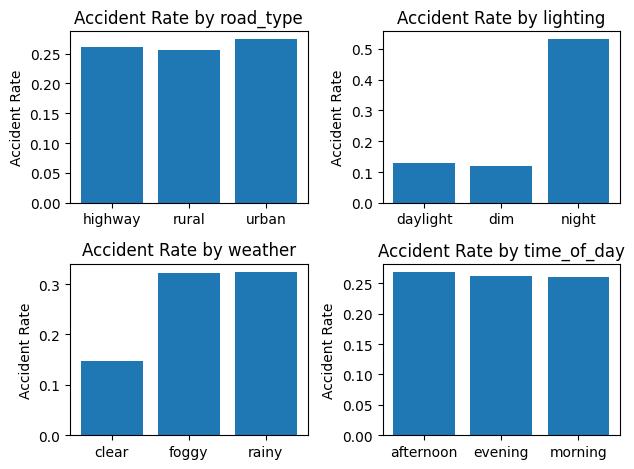

In [ ]:
from matplotlib import pyplot

fig = pyplot.figure()
axes = fig.subplots(2, 2)
axes = axes.flatten()

for index, value in enumerate(categorical_columns):
    accident_rate = (dataframe.groupby(value)['accident'].mean())
    axes[index].bar(accident_rate.index, accident_rate.values)
    axes[index].set_title(f'Accident Rate by {value}')
    axes[index].set_ylabel('Accident Rate')

pyplot.tight_layout()
pyplot.show()

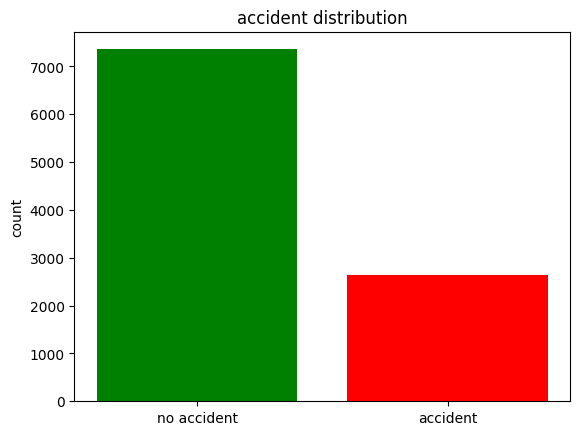

In [ ]:
counts = dataframe['accident'].value_counts()

pyplot.bar(['no accident', 'accident'], counts, color=['green', 'red'])
pyplot.title('accident distribution')
pyplot.ylabel('count')
pyplot.show()

the above graph shows that the dataset is not balanced, this will cause models to guess the majority class every time to achieve high accuracy, failing to actually predict accidents. SMOTENC will balence it, but the dataset needs to be converted to numerical data.

In [ ]:
independent = dataframe.drop('accident', axis=1)
independent.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,time_of_day
0,rural,3.0,0.38,35.0,daylight,foggy,evening
1,highway,2.0,0.50,60.0,daylight,clear,afternoon
2,rural,2.0,0.95,60.0,daylight,clear,afternoon
3,rural,4.0,0.76,25.0,daylight,rainy,afternoon
4,highway,1.0,0.43,60.0,daylight,foggy,evening


In [ ]:
dependent = dataframe['accident']
dependent.unique()

array([0., 1.])

In [ ]:
from sklearn.model_selection import train_test_split

independent_train, independent_test, dependent_train, dependent_test = train_test_split(independent, dependent, test_size=0.3, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
independent_train[numerical_columns] = scaler.fit_transform(independent_train[numerical_columns])
independent_test[numerical_columns] = scaler.transform(independent_test[numerical_columns])

from imblearn.over_sampling import SMOTENC

smotenc = SMOTENC(categorical_features=categorical_columns, random_state=42)
independent_train, dependent_train = smotenc.fit_resample(independent_train, dependent_train)

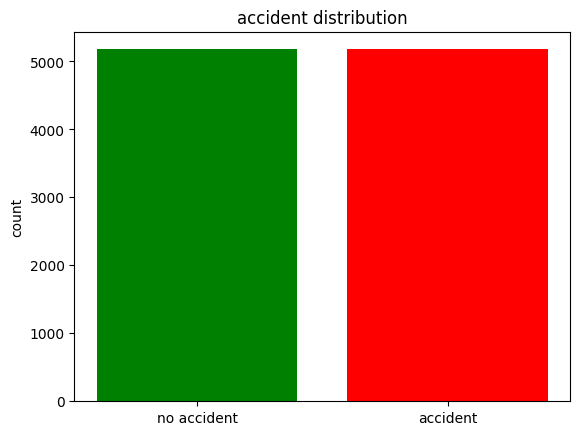

In [ ]:
counts = dependent_train.value_counts()

pyplot.bar(['no accident', 'accident'], counts, color=['green', 'red'])
pyplot.title('accident distribution')
pyplot.ylabel('count')
pyplot.show()

In [ ]:
#converting categorical data to numerical
independent_train = pandas.get_dummies(independent_train, drop_first=True)
independent_test = pandas.get_dummies(independent_test, drop_first=True)

independent_train.shape

(10356, 11)

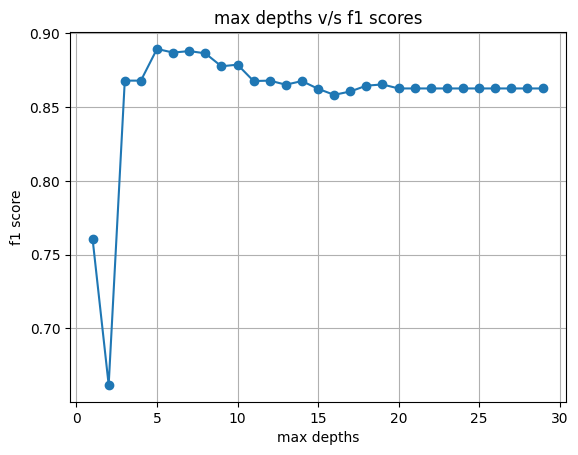

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

f1_scores = []

for i in range(1, 30):
    decision_tree_classifier = DecisionTreeClassifier(max_depth=i, random_state=42)
    decision_tree_classifier.fit(independent_train, dependent_train)

    dependent_prediction = decision_tree_classifier.predict(independent_test)
    f1_scores.append(f1_score(dependent_test, dependent_prediction, average='weighted'))

pyplot.plot(range(1,30), f1_scores, marker='o')
pyplot.title('max depths v/s f1 scores')
pyplot.xlabel('max depths')
pyplot.ylabel('f1 score')
pyplot.grid()
pyplot.show()

from the above graph 5 is a good depth for this decision tree.

In [ ]:
decision_tree_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
decision_tree_classifier.fit(independent_train, dependent_train)

dependent_prediction = decision_tree_classifier.predict(independent_test)

from sklearn.metrics import recall_score, precision_score

decision_tree_recall_accident = round(recall_score(dependent_test, dependent_prediction), 2)
decision_tree_precision_accident = round(precision_score(dependent_test, dependent_prediction), 2)
decision_tree_f1_score = round(f1_score(dependent_test, dependent_prediction, average='weighted'), 2)

from sklearn.metrics import classification_report

print(classification_report(dependent_test, dependent_prediction, target_names = ["no accident", "accident"]))

              precision    recall  f1-score   support

 no accident       0.94      0.90      0.92      2179
    accident       0.76      0.85      0.81       818

    accuracy                           0.89      2997
   macro avg       0.85      0.88      0.86      2997
weighted avg       0.89      0.89      0.89      2997



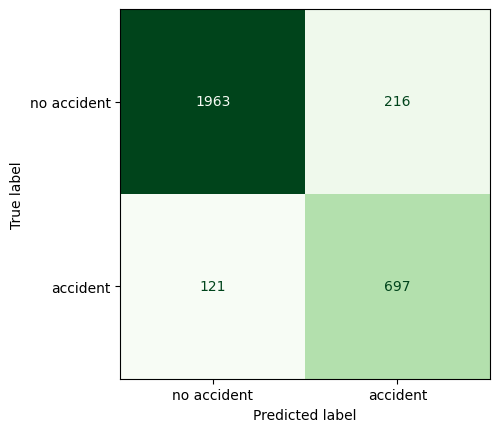

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(dependent_test, dependent_prediction, display_labels = ["no accident", "accident"], cmap='Greens', colorbar=False)

visualizing a tree of 5 levels is difficult, therefore to demonstrate, a tree of 3 levels is visualised

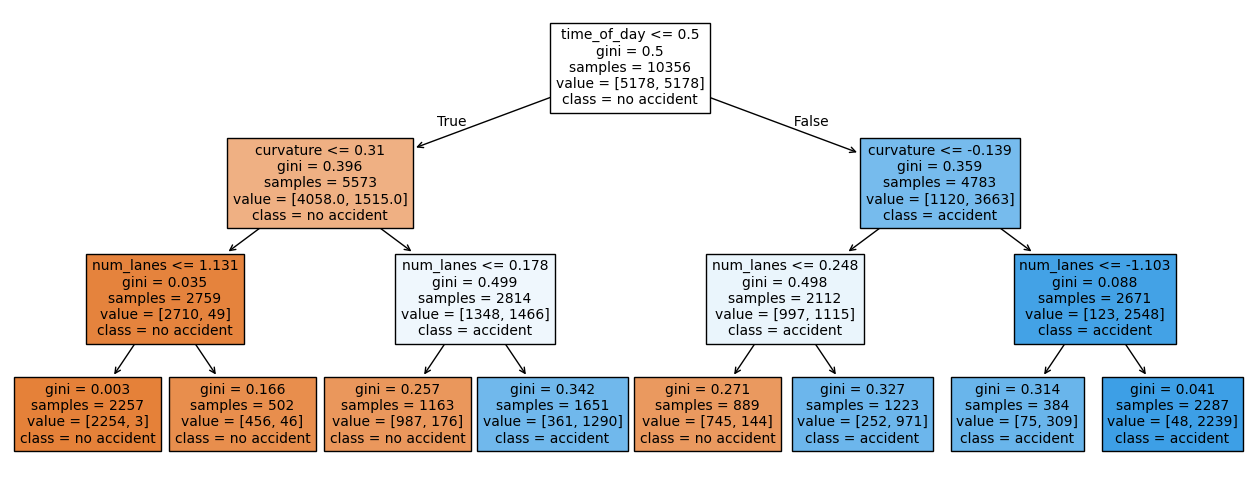

In [76]:
decision_tree_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
decision_tree_classifier.fit(independent_train, dependent_train)

from matplotlib import pyplot
from sklearn.tree import plot_tree

pyplot.figure(figsize = [16, 6])
plot_tree(decision_tree_classifier, feature_names = independent.columns, class_names = ["no accident", "accident"], filled = True, fontsize = 10)
pyplot.show()

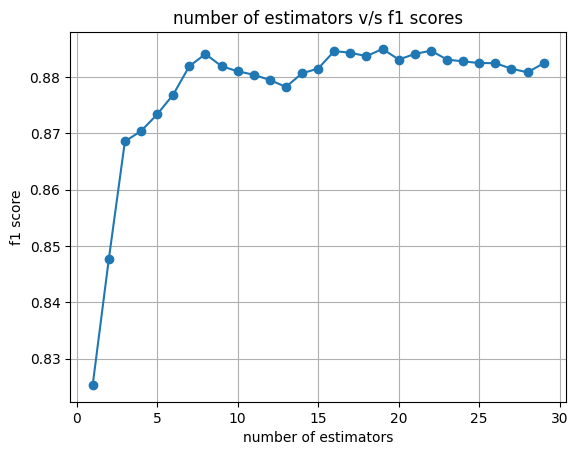

In [ ]:
from sklearn.ensemble import RandomForestClassifier

f1_scores = []

for i in range(1, 30):
    random_forest_classifier = RandomForestClassifier(n_estimators=i, max_depth=5, random_state=42, n_jobs=-1)
    random_forest_classifier.fit(independent_train, dependent_train)

    dependent_prediction = random_forest_classifier.predict(independent_test)
    f1_scores.append(f1_score(dependent_test, dependent_prediction, average='weighted'))

pyplot.plot(range(1,30), f1_scores, marker='o')
pyplot.title('number of estimators v/s f1 scores')
pyplot.xlabel('number of estimators')
pyplot.ylabel('f1 score')
pyplot.grid()
pyplot.show()

from the above graph 8 is a good number of estimators for this random forest

In [ ]:
random_forest_classifier = RandomForestClassifier(n_estimators=8, max_depth=8, random_state=42, n_jobs=-1)
random_forest_classifier.fit(independent_train, dependent_train)

dependent_prediction = random_forest_classifier.predict(independent_test)

random_forest_recall_accident = round(recall_score(dependent_test, dependent_prediction), 2)
random_forest_precision_accident = round(precision_score(dependent_test, dependent_prediction), 2)
random_forest_f1_score = round(f1_score(dependent_test, dependent_prediction, average='weighted'), 2)

print(classification_report(dependent_test, dependent_prediction, target_names = ["no accident", "accident"]))

              precision    recall  f1-score   support

 no accident       0.95      0.90      0.92      2179
    accident       0.76      0.88      0.82       818

    accuracy                           0.89      2997
   macro avg       0.86      0.89      0.87      2997
weighted avg       0.90      0.89      0.89      2997



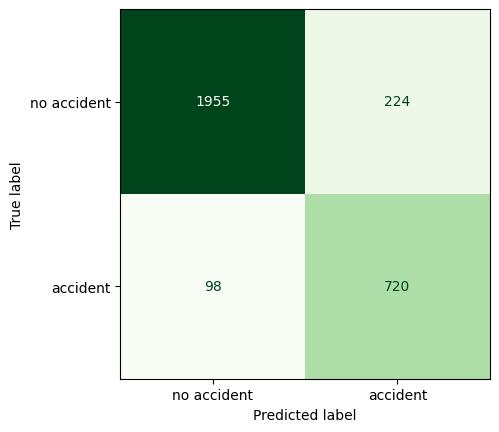

In [ ]:
ConfusionMatrixDisplay.from_predictions(dependent_test, dependent_prediction, display_labels = ["no accident", "accident"], cmap='Greens', colorbar=False)

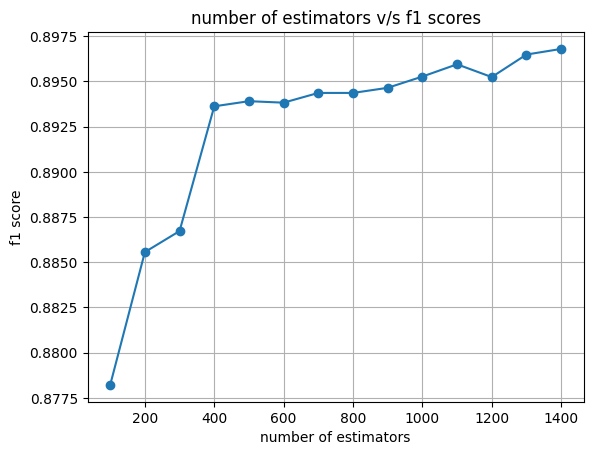

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

f1_scores = []

for i in range(100, 1500, 100):
    ada_boost_classifier = AdaBoostClassifier(n_estimators=i, learning_rate=0.1, random_state=42)
    #not specifying the max_depth as ada boost uses trees of 1 level
    ada_boost_classifier.fit(independent_train, dependent_train)

    dependent_prediction = ada_boost_classifier.predict(independent_test)
    f1_scores.append(f1_score(dependent_test, dependent_prediction, average='weighted'))

pyplot.plot(range(100, 1500, 100), f1_scores, marker='o')
pyplot.title('number of estimators v/s f1 scores')
pyplot.xlabel('number of estimators')
pyplot.ylabel('f1 score')
pyplot.grid()
pyplot.show()

from the above graph 400 is a good number of estimators for this ada boost

In [ ]:
ada_boost_classifier = AdaBoostClassifier(n_estimators=400, learning_rate=0.1, random_state=42)
ada_boost_classifier.fit(independent_train, dependent_train)

dependent_prediction = ada_boost_classifier.predict(independent_test)

ada_boost_recall_accident = round(recall_score(dependent_test, dependent_prediction), 2)
ada_boost_precision_accident = round(precision_score(dependent_test, dependent_prediction), 2)
ada_boost_f1_score = round(f1_score(dependent_test, dependent_prediction, average='weighted'), 2)

print(classification_report(dependent_test, dependent_prediction, target_names = ["no accident", "accident"]))

              precision    recall  f1-score   support

 no accident       0.96      0.88      0.92      2179
    accident       0.75      0.91      0.82       818

    accuracy                           0.89      2997
   macro avg       0.85      0.90      0.87      2997
weighted avg       0.90      0.89      0.89      2997



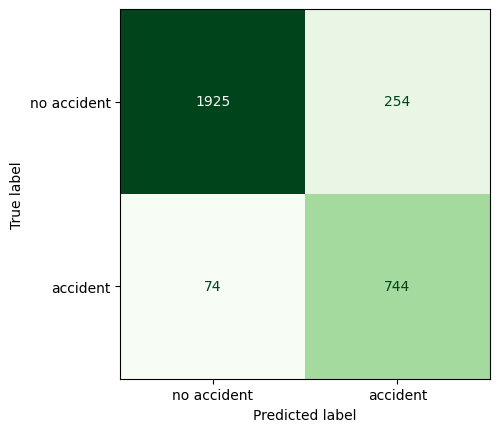

In [ ]:
ConfusionMatrixDisplay.from_predictions(dependent_test, dependent_prediction, display_labels = ["no accident", "accident"], cmap='Greens', colorbar=False)

In [ ]:
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

set_random_seed(42)

model = Sequential([
    #input shape
    Input((11,)),

    #hidden layers: 16 and 8 neurons
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),

    #prevents overfitting by randomly turning off neurons
    Dropout(0.2),

    #output layer: 1 neuron with sigmoid for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(independent_train, dependent_train, epochs=50, batch_size=32, verbose=2)

Epoch 1/50
324/324 - 3s - 8ms/step - accuracy: 0.6653 - loss: 0.6215
Epoch 2/50
324/324 - 1s - 2ms/step - accuracy: 0.8610 - loss: 0.4574
Epoch 3/50
324/324 - 1s - 2ms/step - accuracy: 0.8791 - loss: 0.3966
Epoch 4/50
324/324 - 1s - 2ms/step - accuracy: 0.8869 - loss: 0.3604
Epoch 5/50
324/324 - 1s - 2ms/step - accuracy: 0.8887 - loss: 0.3379
Epoch 6/50
324/324 - 1s - 2ms/step - accuracy: 0.8913 - loss: 0.3217
Epoch 7/50
324/324 - 1s - 2ms/step - accuracy: 0.8924 - loss: 0.3075
Epoch 8/50
324/324 - 1s - 2ms/step - accuracy: 0.8934 - loss: 0.2974
Epoch 9/50
324/324 - 1s - 2ms/step - accuracy: 0.8964 - loss: 0.2856
Epoch 10/50
324/324 - 1s - 2ms/step - accuracy: 0.8979 - loss: 0.2794
Epoch 11/50
324/324 - 1s - 3ms/step - accuracy: 0.9008 - loss: 0.2722
Epoch 12/50
324/324 - 1s - 3ms/step - accuracy: 0.8985 - loss: 0.2691
Epoch 13/50
324/324 - 1s - 3ms/step - accuracy: 0.9013 - loss: 0.2590
Epoch 14/50
324/324 - 1s - 3ms/step - accuracy: 0.8989 - loss: 0.2632
Epoch 15/50
324/324 - 1s - 2m

In [ ]:
probabilities = model.predict(independent_test, verbose=2)
dependent_prediction = (probabilities > 0.5).astype(int)

neural_network_recall_accident = round(recall_score(dependent_test, dependent_prediction), 2)
neural_network_precision_accident = round(precision_score(dependent_test, dependent_prediction), 2)
neural_network_f1_score = round(f1_score(dependent_test, dependent_prediction, average='weighted'), 2)

print(classification_report(dependent_test, dependent_prediction, target_names = ["no accident", "accident"]))

94/94 - 0s - 3ms/step
              precision    recall  f1-score   support

 no accident       0.95      0.90      0.92      2179
    accident       0.77      0.88      0.82       818

    accuracy                           0.89      2997
   macro avg       0.86      0.89      0.87      2997
weighted avg       0.90      0.89      0.90      2997



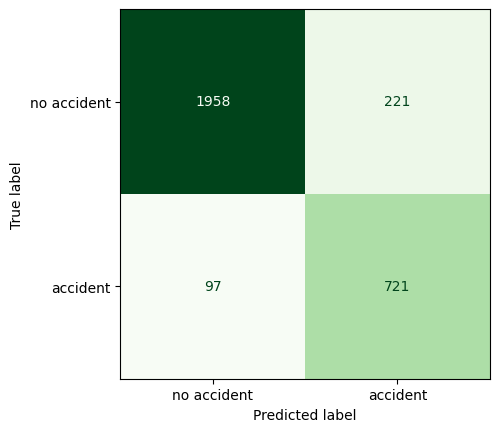

In [ ]:
ConfusionMatrixDisplay.from_predictions(dependent_test, dependent_prediction, display_labels = ["no accident", "accident"], cmap='Greens', colorbar=False)

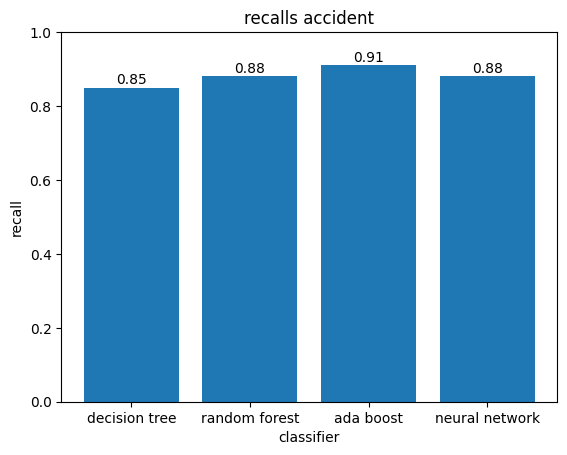

In [ ]:
classifiers = ["decision tree", "random forest", "ada boost", "neural network"]
classifiers_recalls_accident = [decision_tree_recall_accident, random_forest_recall_accident, ada_boost_recall_accident, neural_network_recall_accident]

pyplot.bar(classifiers, classifiers_recalls_accident)

for i in range(len(classifiers_recalls_accident)):
    pyplot.text(i, classifiers_recalls_accident[i] + 0.01, classifiers_recalls_accident[i], ha='center')

pyplot.title('recalls accident')
pyplot.xlabel('classifier')
pyplot.ylabel('recall')
pyplot.ylim(0, 1)

pyplot.show()

from the above graph for the positive class (accident):
*   ada boost has the highest recall
*   decision tree has the lowest recall

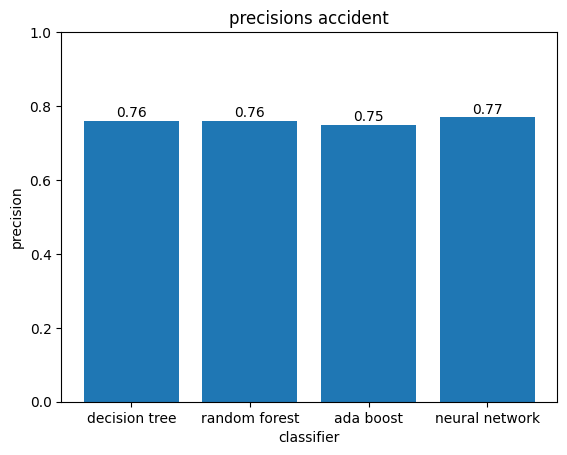

In [ ]:
classifiers_precisions_accident = [decision_tree_precision_accident, random_forest_precision_accident, ada_boost_precision_accident, neural_network_precision_accident]

pyplot.bar(classifiers, classifiers_precisions_accident)

for i in range(len(classifiers_precisions_accident)):
    pyplot.text(i, classifiers_precisions_accident[i] + 0.01, classifiers_precisions_accident[i], ha='center')

pyplot.title('precisions accident')
pyplot.xlabel('classifier')
pyplot.ylabel('precision')
pyplot.ylim(0, 1)

pyplot.show()

from the above graph for the positive class (accident):
*   ada boost has the lowest precision
*   neural network has the highest precision

therefore it can be concluded that:
*   ada boost is more likely to predict an accident when it did not happen, but is less likely to miss a real accident
*   neural network is less likely to predict an accident when it did not happen, but is more likely to miss a real accident

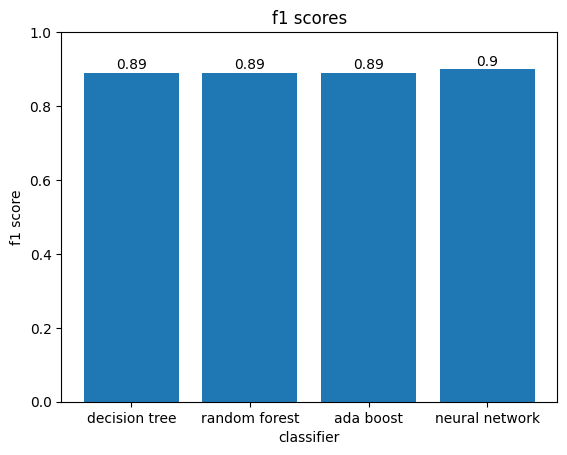

In [ ]:
classifiers_f1_scores = [decision_tree_f1_score, random_forest_f1_score, ada_boost_f1_score, neural_network_f1_score]

pyplot.bar(classifiers, classifiers_f1_scores)

for i in range(len(classifiers_f1_scores)):
    pyplot.text(i, classifiers_f1_scores[i] + 0.01, classifiers_f1_scores[i], ha='center')

pyplot.title('f1 scores')
pyplot.xlabel('classifier')
pyplot.ylabel('f1 score')
pyplot.ylim(0, 1)

pyplot.show()

from the above graph, neural network has the highest overall f1 score

therefore, choosing ada boost in this case is better because:
*   its is better to predict an accident when it did not happen
*   but it is worse to miss a real accident like decision tree

random forest performs similar to neural network, and decision tree is the same as random forest in all cases except recall